In [3]:
from RealTryonDataset import RealTryonDataset

data = RealTryonDataset(root = "data" , garment_pose_path= "data/pose_output.json")
print(data)



<RealTryonDataset | Root: data | Samples: 2032>

person               ca_image             garment_image        pose_path
00006_00.jpg         00006_00.jpg         00006_00.jpg         00006_00_keypoints.json
00008_00.jpg         00008_00.jpg         00008_00.jpg         00008_00_keypoints.json
00013_00.jpg         00013_00.jpg         00013_00.jpg         00013_00_keypoints.json
00017_00.jpg         00017_00.jpg         00017_00.jpg         00017_00_keypoints.json
00034_00.jpg         00034_00.jpg         00034_00.jpg         00034_00_keypoints.json


In [ ]:
import torchvision.transforms.v2 as T
import torch
image_transforms = T.Compose([
        T.ToImage(),
        T.Resize((128, 128)),
        T.ToDtype(torch.float32, scale=True),
    ])

dataset = RealTryonDataset(
        root = "data",
        transforms=image_transforms,
        image_size=(128, 128),
        garment_pose_path= "data/pose_output.json"
    )
dataset

ValueError: garment_pose_path must be provided

In [6]:
pip install matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 4.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


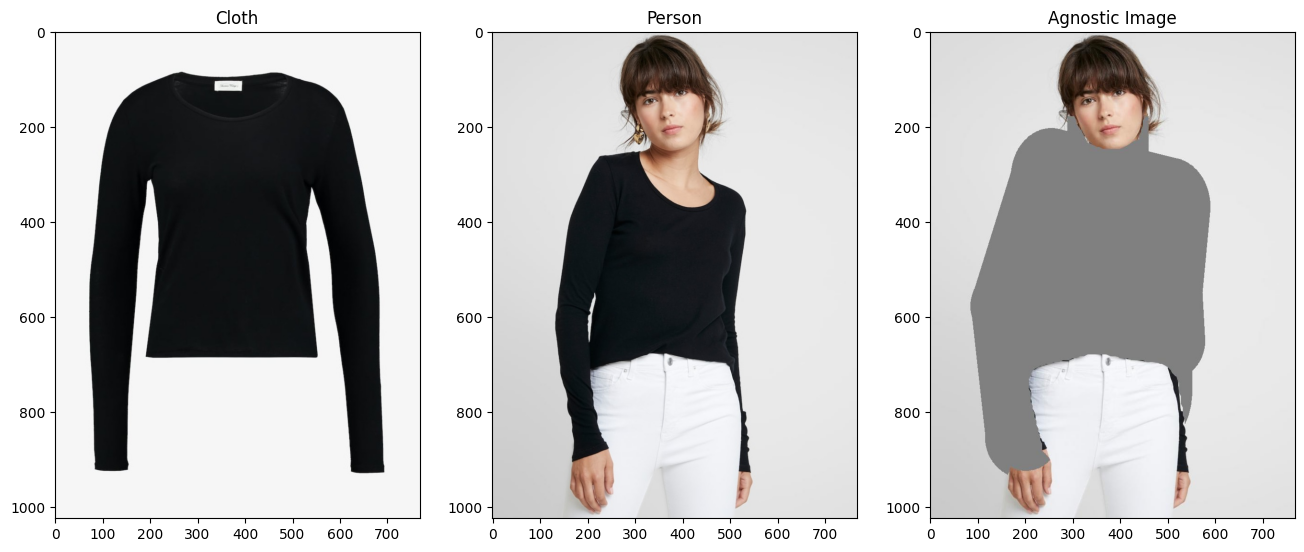

In [2]:
import matplotlib.pyplot as plt
from torchvision.io import read_image

# Assuming these paths are correct relative to your script's execution location
# If not, you'll need to provide the full path or ensure the images are in the
# same directory as your script.
cloth = read_image("examples/garment_images/00006_00.jpg")
person = read_image("examples/person_images/00006_00.jpg")
ca_image = read_image("examples/ca_images/00006_00.jpg")

plt.figure(figsize=(16, 8))

# Displaying the cloth image
plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns, 1st subplot
plt.title("Cloth")
plt.imshow(cloth.permute(1, 2, 0))

# Displaying the person image
plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns, 2nd subplot
plt.title("Person")
plt.imshow(person.permute(1, 2, 0))

# Displaying the ca_image (agnostic image)
plt.subplot(1, 3, 3) # Changed to 1 row, 3 columns, 3rd subplot
plt.title("Agnostic Image")
plt.imshow(ca_image.permute(1, 2, 0))

plt.show()

In [3]:
import os
import torch
import pandas as pd
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
import json
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T

# Configuration
TRAIN_UNET_NUMBER = 1
BASE_UNET_IMAGE_SIZE = (128, 128)
SR_UNET_IMAGE_SIZE = (256, 256)
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 2
NUM_ITERATIONS = 2
TIMESTEPS = (2, 2)


In [28]:
class RealTryonDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None, mapping_file='tryon_mapping.csv', image_size=None):
        self.root = root
        self.transforms = transforms
        self.image_size = image_size
        self.mapping_file_path = os.path.join(root, mapping_file)

        if not os.path.exists(self.mapping_file_path):
            raise FileNotFoundError(f"Mapping file not found at: {self.mapping_file_path}")

        self.data_map = pd.read_csv(self.mapping_file_path)

        required_cols = ['ca_images','garment_images','person_images','person_pose_path']
        if not all(col in self.data_map.columns for col in required_cols):
            raise ValueError(f"Mapping file must contain columns: {required_cols}")

    def __len__(self):
        return len(self.data_map)

    def __getitem__(self, idx):
        row = self.data_map.iloc[idx]

        person_filename = row['person_images']
        ca_filename = row['ca_images']
        garment_filename = row['garment_images']
        person_pose_filename = row['person_pose_path']

        person_path = os.path.join(self.root, "person_images", person_filename)
        ca_path = os.path.join(self.root, "ca_images", ca_filename)
        garment_path = os.path.join(self.root, "garment_images", garment_filename)
        person_pose_path = os.path.join(self.root, "person_pose_path", person_pose_filename)

        for path in [person_path, ca_path, garment_path]:
            if not os.path.exists(path):
                raise FileNotFoundError(f"Image not found: {path}")

        if not os.path.exists(person_pose_path):
            raise FileNotFoundError(f"Pose file not found: {person_pose_path}")

        person_image = tv_tensors.Image(read_image(person_path))
        ca_image = tv_tensors.Image(read_image(ca_path))
        garment_image = tv_tensors.Image(read_image(garment_path))

        # --- FIX: parse pose data ---
        with open(person_pose_path, 'r') as f:
            pose_data = json.load(f)

        # Adjust this based on your JSON structure
        if isinstance(pose_data, dict):
            if "keypoints" in pose_data:
                keypoints = pose_data["keypoints"]  # e.g. [[x1, y1], [x2, y2], ...]
            elif "people" in pose_data and len(pose_data["people"]) > 0:
                raw_keypoints = pose_data["people"][0].get("pose_keypoints_2d", [])
                # Convert from [x1, y1, c1, x2, y2, c2, ...] → [[x1, y1], [x2, y2], ...]
                keypoints = [[raw_keypoints[i], raw_keypoints[i + 1]] for i in range(0, len(raw_keypoints), 3)]
            else:
                raise ValueError(f"Unexpected pose format in file: {person_pose_path}")
        else:
            raise TypeError(f"Expected dict in pose file, got: {type(pose_data)}")

        person_pose = torch.tensor(keypoints, dtype=torch.float32)

        # Apply transforms
        if self.transforms:
            person_image, ca_image, garment_image, person_pose = self.transforms(
                person_image, ca_image, garment_image, person_pose)
        elif self.image_size:
            person_image = F.resize(person_image, self.image_size)
            ca_image = F.resize(ca_image, self.image_size)
            garment_image = F.resize(garment_image, self.image_size)

        return {
            "person_images": person_image,
            "ca_images": ca_image,
            "garment_images": garment_image,
            "person_poses": person_pose,
        }


    def __repr__(self):
        lines = [f"<RealTryonDataset | Root: {self.root} | Samples: {len(self)}>\n"]
        lines.append(f"{'person':<20} {'ca':<20} {'garment':<20} {'pose_path'}")

        preview_rows = min(5, len(self.data_map))
        for idx in range(preview_rows):
            row = self.data_map.iloc[idx]
            lines.append(f"{row['person_images']:<20} {row['ca_images']:<20} "
                        f"{row['garment_images']:<20} {row['person_pose_path']}")
        
        return "\n".join(lines)




In [29]:
dataset = RealTryonDataset(root="./examples")
print(dataset)


<RealTryonDataset | Root: ./examples | Samples: 15>

person               ca                   garment              pose_path
00006_00.jpg         00006_00.jpg         00006_00.jpg         00006_00_keypoints.json
00008_00.jpg         00008_00.jpg         00008_00.jpg         00008_00_keypoints.json
00013_00.jpg         00013_00.jpg         00013_00.jpg         00013_00_keypoints.json
00017_00.jpg         00017_00.jpg         00017_00.jpg         00017_00_keypoints.json
00034_00.jpg         00034_00.jpg         00034_00.jpg         00034_00_keypoints.json


In [30]:
def tryondiffusion_collate_fn(batch):
    return {
        "person_images": torch.stack([item["person_images"] for item in batch]),
        "ca_images": torch.stack([item["ca_images"] for item in batch]),
        "garment_images": torch.stack([item["garment_images"] for item in batch]),
        "person_poses": torch.stack([item["person_poses"] for item in batch]),
    }

In [31]:
def main():
    dataset_root = "./examples"
    
    os.makedirs(os.path.join(dataset_root, "person_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "ca_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "garment_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "person_pose_data"), exist_ok=True)

    image_transforms = T.Compose([
        T.ToImage(),
        T.Resize(SR_UNET_IMAGE_SIZE if TRAIN_UNET_NUMBER == 2 else BASE_UNET_IMAGE_SIZE),
        T.ToDtype(torch.float32, scale=True),
    ])

    dataset = RealTryonDataset(
        root=dataset_root,
        transforms=image_transforms,
        image_size=SR_UNET_IMAGE_SIZE if TRAIN_UNET_NUMBER == 2 else BASE_UNET_IMAGE_SIZE
    )

    train_dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=tryondiffusion_collate_fn,
        num_workers=1
    )

    validation_dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=tryondiffusion_collate_fn,
        num_workers=1
    )

    try:
        from tryondiffusion import TryOnImagen, TryOnImagenTrainer, get_unet_by_name
    except ImportError:
        print("Please install `tryondiffusion`: pip install tryondiffusion")
        return

    print("Checking data loader...")
    sample = next(iter(train_dataloader))
    for k, v in sample.items():
        print(f"{k}: {v.shape}")

    print("Initializing model...")
    base_unet = get_unet_by_name("base")
    sr_unet = get_unet_by_name("sr")

    imagen = TryOnImagen(
        unets=(base_unet, sr_unet),
        image_sizes=(BASE_UNET_IMAGE_SIZE, SR_UNET_IMAGE_SIZE),
        timesteps=TIMESTEPS,
    )

    trainer = TryOnImagenTrainer(
        imagen=imagen,
        max_grad_norm=1.0,
        accelerate_cpu=True,
        accelerate_gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    )

    trainer.add_train_dataloader(train_dataloader)
    trainer.add_valid_dataloader(validation_dataloader)

    for i in range(NUM_ITERATIONS):
        loss = trainer.train_step(unet_number=TRAIN_UNET_NUMBER)
        print(f"Train Loss: {loss}")
        valid_loss = trainer.valid_step(unet_number=TRAIN_UNET_NUMBER)
        print(f"Valid Loss: {valid_loss}")

    print("Sampling results...")
    try:
        validation_sample = next(trainer.valid_dl_iter)
        _ = validation_sample.pop("person_images")

        imagen_sample_kwargs = dict(
            **validation_sample,
            batch_size=BATCH_SIZE,
            cond_scale=2.0,
            start_at_unet_number=1,
            return_all_unet_outputs=True,
            return_pil_images=True,
            use_tqdm=True,
            use_one_unet_in_gpu=True,
        )
        images = trainer.sample(**imagen_sample_kwargs)
        for unet_output in images:
            for image in unet_output:
                image.show()
    except Exception as e:
        print(f"Sampling error: {e}")




In [32]:


if __name__ == "__main__":
    main()

Checking data loader...
person_images: torch.Size([2, 3, 128, 128])
ca_images: torch.Size([2, 3, 128, 128])
garment_images: torch.Size([2, 3, 128, 128])
person_poses: torch.Size([2, 25, 2])
Initializing model...


KeyboardInterrupt: 

In [33]:
import os
import torch
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T
from tryondiffusion import get_unet_by_name

# Constants
BASE_UNET_IMAGE_SIZE = (128, 128)
SR_UNET_IMAGE_SIZE = (256, 256)
TRAIN_UNET_NUMBER = 1
BATCH_SIZE = 2
NUM_KEYPOINTS = 18
MODEL_NAME = "base"
LOWRES_IMAGE = MODEL_NAME == "sr"
MODEL_KWARGS = {}

def main():
    image_size = SR_UNET_IMAGE_SIZE if TRAIN_UNET_NUMBER == 2 else BASE_UNET_IMAGE_SIZE

    unet = get_unet_by_name(MODEL_NAME, **MODEL_KWARGS)
    print(f"Model: {unet.__class__.__name__}")
    print(f"Model parameters: {sum(p.numel() for p in unet.parameters()) / 1e6:.2f}M")

    dataset_root = "./examples"
    os.makedirs(os.path.join(dataset_root, "person_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "ca_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "garment_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "person_pose_path"), exist_ok=True)

    image_transforms = T.Compose([
        T.ToImage(),
        T.Resize(image_size),
        T.ToDtype(torch.float32, scale=True),
    ])

    dataset = RealTryonDataset(
        root=dataset_root,
        transforms=image_transforms,
        image_size=image_size
    )

    train_dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=tryondiffusion_collate_fn,
        num_workers=1
    )

    sample = next(iter(train_dataloader))
    noisy_images = torch.randn(BATCH_SIZE, 3, *image_size)
    lowres_cond_images = torch.randn(BATCH_SIZE, 3, *image_size) if LOWRES_IMAGE else None

    output = unet(
        noisy_images=noisy_images,
        time=torch.randn(BATCH_SIZE),
        lowres_cond_img=lowres_cond_images,
        lowres_noise_times=torch.randn(BATCH_SIZE) if LOWRES_IMAGE else None,
        ca_images=sample["ca_images"],
        ca_noise_times=torch.randn(BATCH_SIZE),
        garment_images=sample["garment_images"],
        garment_noise_times=torch.randn(BATCH_SIZE),
        person_poses=sample["person_poses"],
        garment_poses=torch.randn(BATCH_SIZE, NUM_KEYPOINTS, 2),
    )

    print(f"Output shape: {output.shape}")

if __name__ == "__main__":
    main()


Model: BaseParallelUnet
Model parameters: 1295.56M


IndexError: index out of range in self

In [ ]:
import os
import torch
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T
from tryondiffusion import get_unet_by_name

# Constants
BASE_UNET_IMAGE_SIZE = (128, 128)
SR_UNET_IMAGE_SIZE = (256, 256)
TRAIN_UNET_NUMBER = 1
BATCH_SIZE = 2
NUM_KEYPOINTS = 18  # Adjust if your pose data uses more/fewer keypoints
MODEL_NAME = "base"
LOWRES_IMAGE = MODEL_NAME == "sr"
MODEL_KWARGS = {}

def main():
    image_size = SR_UNET_IMAGE_SIZE if TRAIN_UNET_NUMBER == 2 else BASE_UNET_IMAGE_SIZE

    unet = get_unet_by_name(MODEL_NAME, **MODEL_KWARGS)
    print(f"Model: {unet.__class__.__name__}")
    print(f"Model parameters: {sum(p.numel() for p in unet.parameters()) / 1e6:.2f}M")

    dataset_root = "./examples"
    os.makedirs(os.path.join(dataset_root, "person_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "ca_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "garment_images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_root, "person_pose_path"), exist_ok=True)

    image_transforms = T.Compose([
        T.ToImage(),
        T.Resize(image_size),
        T.ToDtype(torch.float32, scale=True),
    ])

    dataset = RealTryonDataset(
        root=dataset_root,
        transforms=image_transforms,
        image_size=image_size
    )

    train_dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=tryondiffusion_collate_fn,
        num_workers=1
    )

    sample = next(iter(train_dataloader))
    noisy_images = torch.randn(BATCH_SIZE, 3, *image_size)
    lowres_cond_images = torch.randn(BATCH_SIZE, 3, *image_size) if LOWRES_IMAGE else None

    print(f"Loaded batch keys: {list(sample.keys())}")
    print(f"Person poses shape: {sample['person_poses'].shape}")

    # Ensure pose shape matches expected input
    if sample["person_poses"].shape[1] != NUM_KEYPOINTS:
        sample["person_poses"] = sample["person_poses"][:, :NUM_KEYPOINTS, :]

    garment_poses = torch.randn(BATCH_SIZE, NUM_KEYPOINTS, 2)

    output = unet(
        noisy_images=noisy_images,
        time=torch.randn(BATCH_SIZE),
        lowres_cond_img=lowres_cond_images,
        lowres_noise_times=torch.randn(BATCH_SIZE) if LOWRES_IMAGE else None,
        ca_images=sample["ca_images"],
        ca_noise_times=torch.randn(BATCH_SIZE),
        garment_images=sample["garment_images"],
        garment_noise_times=torch.randn(BATCH_SIZE),
        person_poses=sample["person_poses"],
        garment_poses=garment_poses,
    )

    print(f"Output shape: {output.shape}")

if __name__ == "__main__":
    main()
